# NB-06 · DINOv2-Guided SegFormer-B0 for Brain Tumour MRI Semantic Segmentation

**Course:** CSE 438: Digital Image Processing  
**Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of Computer Science and Engineering  
**Institution:** East West University (EWU)

---

## Notebook objective

This notebook addresses binary brain-tumour semantic segmentation from MRI images annotated in **COCO polygon format**:

\[
0=\text{background}, \qquad 1=\text{tumour region}.
\]

It combines two transformer-based ideas through a methodologically valid training design:

- **DINOv2 ViT-S/14** acts as a frozen, self-supervised visual **teacher**.
- **SegFormer-B0** acts as the trainable semantic-segmentation **student**.

### Why feature guidance is used instead of encoder weight transfer

DINOv2 and SegFormer do not have the same encoder architecture. DINOv2 is a Vision Transformer producing patch-token features, whereas SegFormer uses a hierarchical **Mix Transformer (MiT)** encoder and an all-MLP decoder. Therefore, DINOv2 weights cannot be copied directly into SegFormer-B0 without an architectural mismatch.

The notebook instead aligns the final SegFormer encoder feature map with a spatial DINOv2 teacher feature map during supervised training:

\[
\mathcal{L}_{total}
=
\mathcal{L}_{CE}
+
0.70\mathcal{L}_{Dice}
+
\lambda_{KD}\mathcal{L}_{feature}.
\]

The trained SegFormer student alone is used for final inference; DINOv2 is required only during teacher-guided training and representation analysis.

### Learning outcomes

Students completing this notebook should be able to:

1. rasterise COCO polygons into merged binary semantic masks;
2. explain why weights from incompatible encoders cannot be transferred directly;
3. implement representation-level teacher guidance for segmentation;
4. fine-tune SegFormer-B0 using stable CUDA and AMP procedures;
5. interpret Dice, IoU, probability maps, error maps, feature-response maps, alignment trends, and t-SNE plots.

### Principal references

- Oquab *et al.* (2023), **DINOv2: Learning Robust Visual Features without Supervision**, arXiv:2304.07193.
- Xie *et al.* (2021), **SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers**, arXiv:2105.15203.
- Hugging Face documentation: `Dinov2Model`, `SegformerModel`, and `SegformerForSemanticSegmentation`.

> **Kaggle model-access note:** The teacher-guidance objective is activated only when pretrained DINOv2 weights can be loaded from the local Hugging Face cache or downloaded with Kaggle Internet enabled. When unavailable, the notebook clearly disables teacher guidance and trains a supervised SegFormer baseline rather than pretending that a random teacher represents DINOv2 knowledge.

## 1. Configuration and imports

All experimental outputs are written to `/kaggle/working/dinov2_guided_segformer_brain_tumour`.  
The fixed dataset path follows the course dataset configuration.

In [1]:
# =============================================================================
# Core imports and experimental configuration
# =============================================================================
import os
import gc
import json
import math
import random
import copy
from pathlib import Path
from collections import defaultdict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import ColorJitter
from torchvision.transforms.functional import InterpolationMode

from transformers import (
    Dinov2Model,
    SegformerConfig,
    SegformerModel,
    SegformerForSemanticSegmentation,
)
from sklearn.manifold import TSNE
from tqdm.auto import tqdm

# -----------------------------------------------------------------------------
# Required Kaggle dataset path and output folders
# -----------------------------------------------------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")

OUTPUT_DIR = Path("/kaggle/working/dinov2_guided_segformer_brain_tumour")
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Reproducible training configuration
# -----------------------------------------------------------------------------
SEED = 438
IMG_SIZE = 224                      # Divisible by DINOv2 patch size 14 and MiT downsampling.
NUM_CLASSES = 2                     # Background and tumour.
EPOCHS = 10
WARMUP_EPOCHS = 2                   # Train decoder/adapter first; unfreeze MiT after warm-up.
DINO_MODEL_NAME = "facebook/dinov2-small"
SEGFORMER_ENCODER_NAME = "nvidia/mit-b0"

DECODER_LR = 2e-4
ENCODER_LR = 1e-5
WEIGHT_DECAY = 1e-4
DICE_WEIGHT = 0.70
DISTILLATION_WEIGHT = 0.15          # Applied only when a pretrained DINOv2 teacher is available.

CLASS_NAMES = ["background", "tumour"]

def seed_everything(seed: int = SEED) -> None:
    """Set seeds for reproducible classroom experimentation where feasible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

print(f"Dataset root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
Output directory: /kaggle/working/dinov2_guided_segformer_brain_tumour


## 2. CUDA kernel probe and AMP safety policy

The notebook attempts CUDA execution only after a small kernel-and-backpropagation probe succeeds. This check prevents a visible but incompatible GPU runtime from terminating the training loop. AMP is activated only after the probe passes. No `channels_last` memory conversions are used.

In [2]:
def select_safe_device():
    """
    Check whether a usable CUDA kernel can execute before selecting the GPU.
    When the test fails, CPU execution is selected automatically.
    """
    if not torch.cuda.is_available():
        print("CUDA is not visible in this runtime. CPU execution selected; AMP disabled.")
        return torch.device("cpu"), False

    try:
        test_input = torch.randn(2, 3, 32, 32, device="cuda", requires_grad=True)
        test_layer = nn.Conv2d(3, 4, kernel_size=3, padding=1).to("cuda")
        test_value = test_layer(test_input).square().mean()
        test_value.backward()
        torch.cuda.synchronize()

        device_name = torch.cuda.get_device_name(0)
        del test_input, test_layer, test_value
        torch.cuda.empty_cache()

        print(f"CUDA kernel probe passed: {device_name}")
        print("AMP is enabled for model forward passes.")
        return torch.device("cuda"), True

    except Exception as error:
        print("CUDA is visible but cannot execute the required kernels.")
        print(f"Diagnostic message: {type(error).__name__}: {str(error)[:260]}")
        print("CPU fallback selected; AMP disabled.")
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        return torch.device("cpu"), False


device, AMP_ENABLED = select_safe_device()

# The teacher and the segmentation student both occupy memory during training.
# A conservative batch size is used for Kaggle GPUs.
BATCH_SIZE = 4 if device.type == "cuda" else 2
NUM_WORKERS = 2 if device.type == "cuda" else 0
PIN_MEMORY = device.type == "cuda"

def amp_context():
    """Return an AMP context only when CUDA has passed the execution probe."""
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

try:
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print(f"Selected device: {device}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"Batch size: {BATCH_SIZE}")

CUDA kernel probe passed: Tesla T4
AMP is enabled for model forward passes.
Selected device: cuda
AMP enabled: True
Batch size: 4


## 3. Converting COCO polygons into binary tumour masks

COCO annotations may contain several polygon components for one image. For semantic segmentation, all polygon components are filled into one foreground target. The model therefore predicts **tumour presence at each pixel**, rather than separate object instances.

In [3]:
# =============================================================================
# COCO polygon reader and mask rasterisation
# =============================================================================
def read_coco_split(split_directory: Path):
    """Read one COCO annotation file and map annotations to their image identifiers."""
    annotation_file = split_directory / "_annotations.coco.json"
    if not annotation_file.exists():
        raise FileNotFoundError(f"Annotation file was not found: {annotation_file}")

    with open(annotation_file, "r", encoding="utf-8") as file:
        coco_data = json.load(file)

    annotations_by_image = defaultdict(list)
    for annotation in coco_data.get("annotations", []):
        annotations_by_image[annotation["image_id"]].append(annotation)

    valid_image_records = []
    for image_record in coco_data.get("images", []):
        image_path = split_directory / image_record["file_name"]
        if image_path.exists():
            valid_image_records.append(image_record)
        else:
            print(f"Warning: JSON entry has no corresponding image file: {image_path}")

    return valid_image_records, annotations_by_image


def coco_polygons_to_binary_mask(image_record: dict, annotations: list) -> Image.Image:
    """
    Merge every polygon belonging to one MRI slice into one semantic mask.
    Mask pixel values remain 0 for background and 1 for tumour.
    """
    width = int(image_record["width"])
    height = int(image_record["height"])
    mask = Image.new("L", (width, height), color=0)
    draw = ImageDraw.Draw(mask)

    for annotation in annotations:
        segmentation = annotation.get("segmentation", [])
        if not isinstance(segmentation, list):
            raise ValueError(
                "An RLE segmentation was detected. "
                "This laboratory notebook is specified for COCO polygon annotations."
            )

        for polygon in segmentation:
            if len(polygon) >= 6:
                vertices = [
                    (polygon[position], polygon[position + 1])
                    for position in range(0, len(polygon), 2)
                ]
                draw.polygon(vertices, outline=1, fill=1)

    return mask


class BrainTumourCocoSegmentationDataset(Dataset):
    """Dataset class returning normalised MRI tensors and merged semantic masks."""

    def __init__(self, split_directory: Path, image_size: int = IMG_SIZE, training: bool = False):
        self.split_directory = split_directory
        self.image_size = image_size
        self.training = training
        self.image_records, self.annotations_by_image = read_coco_split(split_directory)

        # Mild intensity changes preserve the structural content of MRI slices.
        self.intensity_transform = ColorJitter(brightness=0.10, contrast=0.10)

        # DINOv2 and ImageNet-pretrained vision models commonly use this normalisation.
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __len__(self):
        return len(self.image_records)

    def load_original_pair(self, index: int):
        """Return the original-resolution MRI image and its merged binary mask."""
        image_record = self.image_records[index]
        image = Image.open(self.split_directory / image_record["file_name"]).convert("RGB")
        mask = coco_polygons_to_binary_mask(
            image_record,
            self.annotations_by_image.get(image_record["id"], [])
        )
        return image, mask

    def __getitem__(self, index: int):
        image, mask = self.load_original_pair(index)

        image = TF.resize(
            image, [self.image_size, self.image_size], interpolation=InterpolationMode.BILINEAR
        )
        mask = TF.resize(
            mask, [self.image_size, self.image_size], interpolation=InterpolationMode.NEAREST
        )

        # Every spatial operation is applied jointly to image and mask.
        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.35:
                angle = random.uniform(-10.0, 10.0)
                image = TF.rotate(
                    image, angle, interpolation=InterpolationMode.BILINEAR, fill=0
                )
                mask = TF.rotate(
                    mask, angle, interpolation=InterpolationMode.NEAREST, fill=0
                )

            image = self.intensity_transform(image)

        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=self.mean, std=self.std)

        mask_array = np.array(mask, dtype=np.int64)
        mask_tensor = torch.from_numpy((mask_array > 0).astype(np.int64)).long()

        # The notebook deliberately retains standard contiguous tensors.
        return image_tensor.contiguous(), mask_tensor.contiguous()

In [4]:
# =============================================================================
# Datasets and data loaders
# =============================================================================
train_dataset = BrainTumourCocoSegmentationDataset(DATA_ROOT / "train", training=True)
valid_dataset = BrainTumourCocoSegmentationDataset(DATA_ROOT / "valid", training=False)
test_dataset = BrainTumourCocoSegmentationDataset(DATA_ROOT / "test", training=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Number of images": [len(train_dataset), len(valid_dataset), len(test_dataset)]
})
display(split_summary)

,Split,Number of images
0,Train,1502
1,Validation,429
2,Test,215


## 4. Data audit and annotation visualisation

The tumour region commonly occupies a small fraction of each MRI slice. The foreground-area distribution is inspected before modelling because it motivates overlap-based metrics such as Dice and IoU.

Auditing train masks:   0%|          | 0/1502 [00:00<?, ?it/s]

Auditing valid masks:   0%|          | 0/429 [00:00<?, ?it/s]

Auditing test masks:   0%|          | 0/215 [00:00<?, ?it/s]

,Split,Number of images,Images containing foreground,Mean foreground area (%)
0,Train,1502,1501,3.711
1,Validation,429,429,3.723
2,Test,215,215,3.711


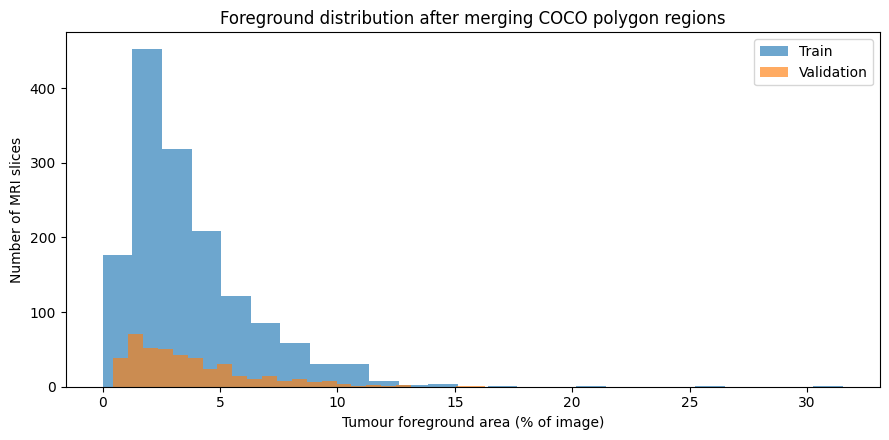

In [5]:
def foreground_area_fractions(dataset):
    """Compute the foreground proportion in each original-resolution mask."""
    fractions = []
    for index in tqdm(range(len(dataset)), desc=f"Auditing {dataset.split_directory.name} masks"):
        _, mask = dataset.load_original_pair(index)
        fractions.append(np.asarray(mask, dtype=np.float32).mean())
    return np.asarray(fractions)


train_fractions = foreground_area_fractions(train_dataset)
valid_fractions = foreground_area_fractions(valid_dataset)
test_fractions = foreground_area_fractions(test_dataset)

foreground_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Number of images": [len(train_fractions), len(valid_fractions), len(test_fractions)],
    "Images containing foreground": [
        int((train_fractions > 0).sum()),
        int((valid_fractions > 0).sum()),
        int((test_fractions > 0).sum())
    ],
    "Mean foreground area (%)": [
        100 * train_fractions.mean(),
        100 * valid_fractions.mean(),
        100 * test_fractions.mean()
    ]
})
display(foreground_summary.round(3))
foreground_summary.to_csv(OUTPUT_DIR / "dataset_foreground_summary.csv", index=False)

plt.figure(figsize=(9, 4.5))
plt.hist(train_fractions * 100, bins=25, alpha=0.65, label="Train")
plt.hist(valid_fractions * 100, bins=25, alpha=0.65, label="Validation")
plt.xlabel("Tumour foreground area (% of image)")
plt.ylabel("Number of MRI slices")
plt.title("Foreground distribution after merging COCO polygon regions")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "foreground_area_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

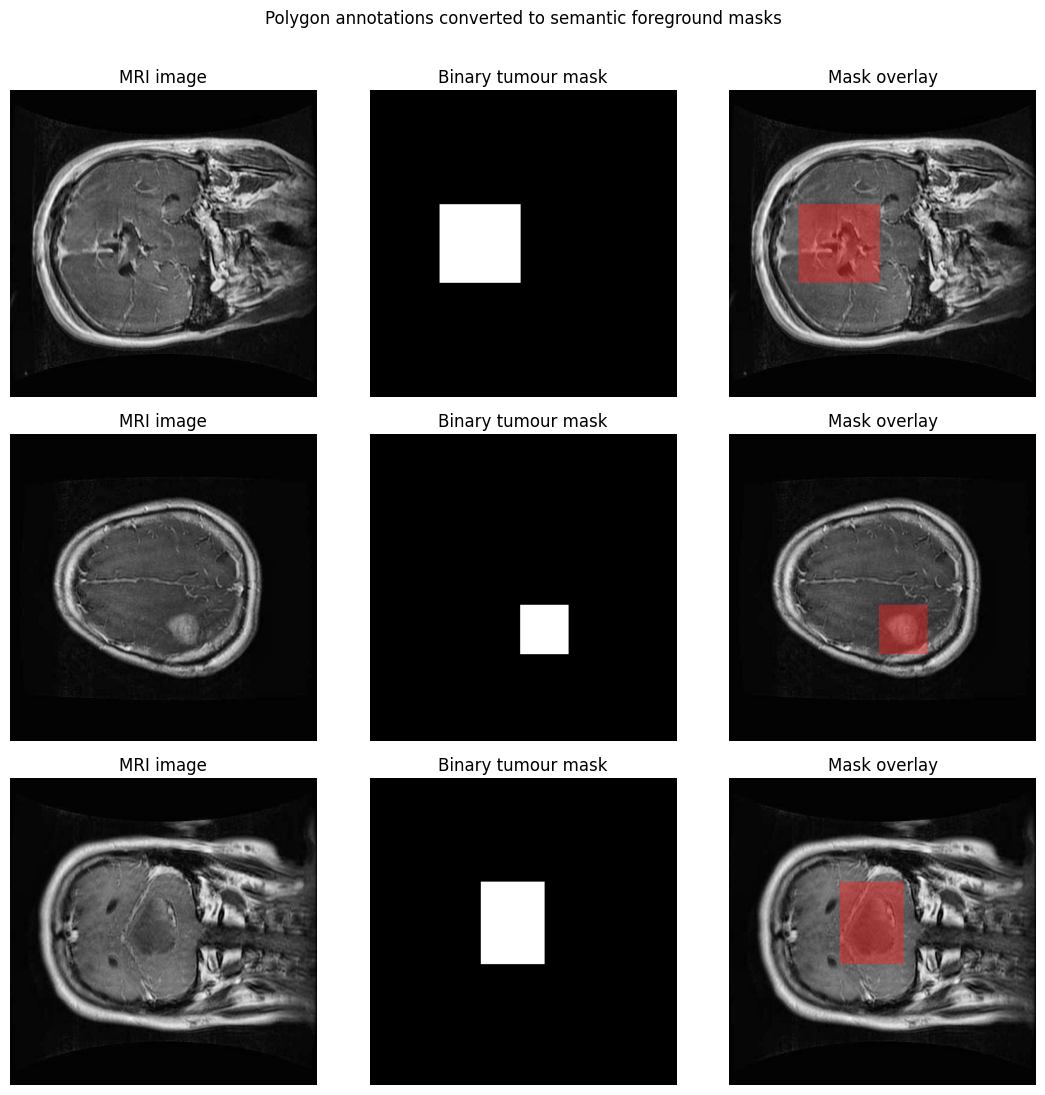

In [6]:
def visualise_annotation_pairs(dataset, area_fractions, number_of_examples=3):
    """Display original MRI slices, binary masks, and red foreground overlays."""
    positive_indices = np.where(area_fractions > 0)[0]
    if len(positive_indices) == 0:
        positive_indices = np.arange(min(number_of_examples, len(dataset)))

    selected_indices = positive_indices[
        np.linspace(
            0, len(positive_indices) - 1,
            min(number_of_examples, len(positive_indices)), dtype=int
        )
    ]

    fig, axes = plt.subplots(len(selected_indices), 3, figsize=(11, 3.6 * len(selected_indices)))
    axes = np.atleast_2d(axes)

    for row, index in enumerate(selected_indices):
        image, mask = dataset.load_original_pair(int(index))
        image_array = np.asarray(image)
        mask_array = np.asarray(mask)

        overlay = image_array.copy().astype(np.float32)
        overlay[mask_array > 0] = (
            0.55 * overlay[mask_array > 0] + 0.45 * np.array([255, 35, 35])
        )

        axes[row, 0].imshow(image_array)
        axes[row, 0].set_title("MRI image")
        axes[row, 1].imshow(mask_array, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Binary tumour mask")
        axes[row, 2].imshow(overlay.astype(np.uint8))
        axes[row, 2].set_title("Mask overlay")

        for axis in axes[row]:
            axis.axis("off")

    plt.suptitle("Polygon annotations converted to semantic foreground masks", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "annotation_overlay_examples.png", dpi=220, bbox_inches="tight")
    plt.show()


visualise_annotation_pairs(train_dataset, train_fractions)

## 5. DINOv2-guided SegFormer training flow

During each training iteration:

1. the MRI batch passes through **SegFormer-B0**, producing semantic logits and a final MiT feature map;
2. the same batch passes through the frozen **DINOv2 teacher**, producing patch-token features;
3. DINOv2 tokens are reshaped into a spatial map and resized to the final MiT feature resolution;
4. a learnable \(1 \times 1\) adapter projects the SegFormer feature channels to the teacher feature dimension;
5. segmentation loss and cosine feature-alignment loss are combined.

After training, inference retains only the SegFormer student and its segmentation head.

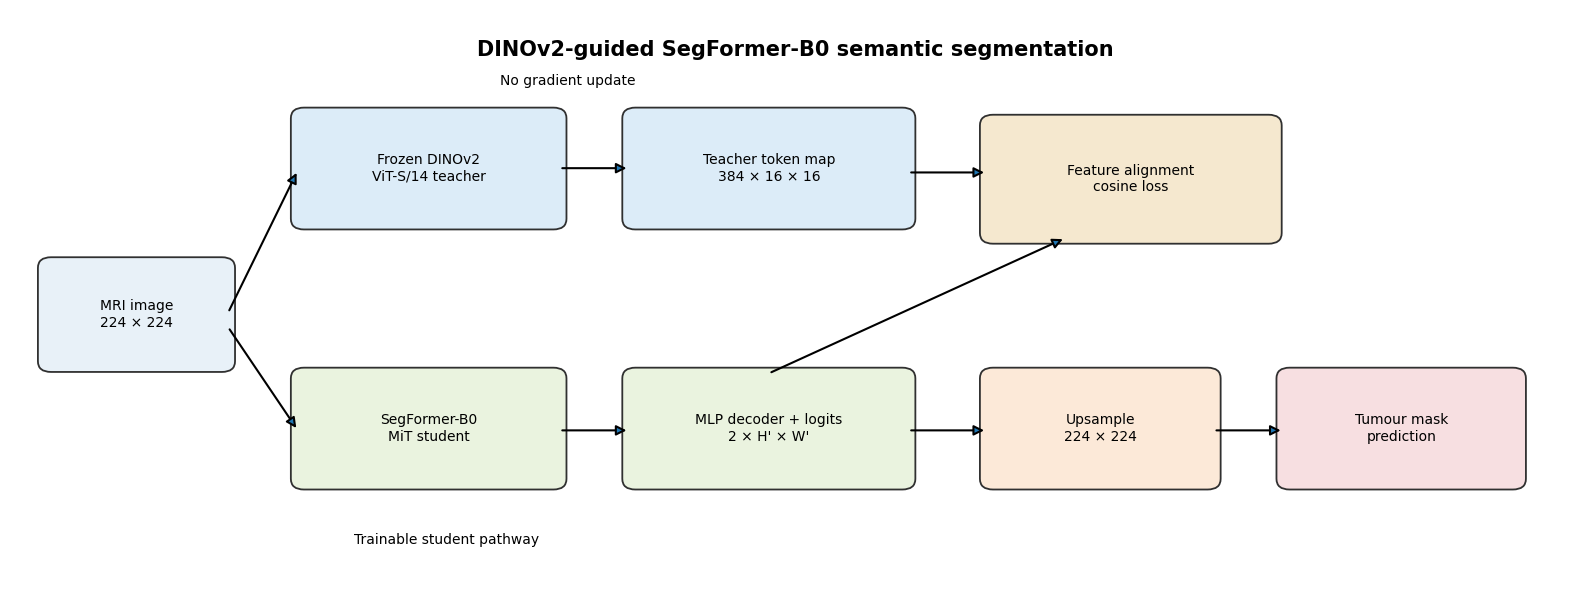

In [7]:
def draw_teacher_student_workflow():
    """Draw an explanatory feature-distillation workflow for classroom interpretation."""
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 8)
    ax.axis("off")

    def box(x, y, width, height, text, colour):
        patch = FancyBboxPatch(
            (x, y), width, height,
            boxstyle="round,pad=0.08,rounding_size=0.15",
            facecolor=colour, edgecolor="#303030", linewidth=1.3
        )
        ax.add_patch(patch)
        ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=10)

    def arrow(start, end):
        ax.add_patch(FancyArrowPatch(
            start, end, arrowstyle="-|>", mutation_scale=15, linewidth=1.5
        ))

    box(0.4, 3.0, 2.1, 1.45, "MRI image\n224 × 224", "#E8F1F8")
    box(3.3, 5.0, 3.0, 1.55, "Frozen DINOv2\nViT-S/14 teacher", "#DCECF8")
    box(7.1, 5.0, 3.2, 1.55, "Teacher token map\n384 × 16 × 16", "#DCECF8")
    box(3.3, 1.35, 3.0, 1.55, "SegFormer-B0\nMiT student", "#EAF3DF")
    box(7.1, 1.35, 3.2, 1.55, "MLP decoder + logits\n2 × H' × W'", "#EAF3DF")
    box(11.2, 1.35, 2.6, 1.55, "Upsample\n224 × 224", "#FCE9D8")
    box(14.6, 1.35, 2.7, 1.55, "Tumour mask\nprediction", "#F7DFE1")
    box(11.2, 4.8, 3.3, 1.65, "Feature alignment\ncosine loss", "#F5E8CF")

    arrow((2.5, 3.75), (3.3, 5.75))
    arrow((2.5, 3.55), (3.3, 2.1))
    arrow((6.3, 5.78), (7.1, 5.78))
    arrow((6.3, 2.1), (7.1, 2.1))
    arrow((10.3, 2.1), (11.2, 2.1))
    arrow((13.8, 2.1), (14.6, 2.1))
    arrow((10.3, 5.72), (11.2, 5.72))
    arrow((8.7, 2.9), (12.1, 4.8))

    ax.text(9.0, 7.35, "DINOv2-guided SegFormer-B0 semantic segmentation",
            ha="center", fontsize=15, fontweight="bold")
    ax.text(5.0, 0.5, "Trainable student pathway", ha="center", fontsize=10)
    ax.text(6.4, 6.95, "No gradient update", ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "dinov2_segformer_feature_guidance_workflow.png", dpi=220, bbox_inches="tight")
    plt.show()


draw_teacher_student_workflow()

## 6. Loading DINOv2 and SegFormer-B0

The code makes three distinctions explicit:

- A **pretrained DINOv2 checkpoint** is necessary for teacher guidance.
- A pretrained **MiT-B0 encoder** is loaded into the SegFormer segmentation model when accessible.
- If pretrained resources cannot be accessed in Kaggle, the notebook remains executable but reports exactly which component is random-initialised or disabled.

In [8]:
# =============================================================================
# Pretrained model loading with transparent fallbacks
# =============================================================================
def load_dinov2_teacher(model_name: str = DINO_MODEL_NAME):
    """
    Load a pretrained DINOv2 teacher. A random teacher is not used for guidance:
    without pretrained teacher weights, feature distillation is disabled.
    """
    for local_only in [True, False]:
        try:
            teacher = Dinov2Model.from_pretrained(model_name, local_files_only=local_only)
            source = "local cache" if local_only else "online model repository"
            status = f"Pretrained DINOv2 teacher loaded from {source}: {model_name}"
            teacher.eval()
            for parameter in teacher.parameters():
                parameter.requires_grad = False
            return teacher, True, status
        except Exception:
            continue

    status = (
        "Pretrained DINOv2 weights could not be loaded. "
        "Feature-guidance loss is disabled; the remaining run is a supervised SegFormer baseline."
    )
    return None, False, status


def build_binary_segformer_config():
    """Create a SegFormer-B0 configuration for two-class semantic segmentation."""
    config = SegformerConfig(
        num_labels=NUM_CLASSES,
        id2label={0: "background", 1: "tumour"},
        label2id={"background": 0, "tumour": 1},
    )
    return config


def load_segformer_student(encoder_name: str = SEGFORMER_ENCODER_NAME):
    """
    Initialise a SegFormer segmentation model and load MiT-B0 encoder weights
    when the checkpoint is available. The segmentation head is task-specific.
    """
    for local_only in [True, False]:
        try:
            config = SegformerConfig.from_pretrained(
                encoder_name,
                num_labels=NUM_CLASSES,
                id2label={0: "background", 1: "tumour"},
                label2id={"background": 0, "tumour": 1},
                local_files_only=local_only,
            )
            encoder = SegformerModel.from_pretrained(
                encoder_name, local_files_only=local_only
            )
            student = SegformerForSemanticSegmentation(config)
            student.segformer.load_state_dict(encoder.state_dict(), strict=True)

            source = "local cache" if local_only else "online model repository"
            status = (
                f"MiT-B0 encoder weights loaded from {source}: {encoder_name}. "
                "The binary segmentation decoder is initialised for this task."
            )
            del encoder
            return student, status
        except Exception:
            continue

    student = SegformerForSemanticSegmentation(build_binary_segformer_config())
    status = (
        "MiT-B0 pretrained weights could not be loaded. "
        "SegFormer-B0 is randomly initialised for executable demonstration."
    )
    return student, status


dino_teacher, DINO_GUIDANCE_ENABLED, DINO_STATUS = load_dinov2_teacher()
segformer_student, SEGFORMER_STATUS = load_segformer_student()

print(DINO_STATUS)
print(SEGFORMER_STATUS)
print(f"Teacher-guided feature loss active: {DINO_GUIDANCE_ENABLED}")

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pretrained DINOv2 teacher loaded from online model repository: facebook/dinov2-small
MiT-B0 encoder weights loaded from online model repository: nvidia/mit-b0. The binary segmentation decoder is initialised for this task.
Teacher-guided feature loss active: True


## 7. DINOv2-guided SegFormer model

For a \(224 \times 224\) input, DINOv2 ViT-S/14 produces a \(16 \times 16\) patch-token map. SegFormer produces hierarchical MiT feature maps; the final student representation is aligned to the teacher representation after spatial resizing and a learnable \(1 \times 1\) channel adapter.

The teacher remains frozen. Consequently, gradients update the SegFormer student and its adapter, not DINOv2.

In [9]:
# =============================================================================
# Teacher-student wrapper
# =============================================================================
def ensure_spatial_map(feature_tensor: torch.Tensor) -> torch.Tensor:
    """
    Convert a token sequence to a square spatial map when necessary.
    Hugging Face SegFormer hidden states are normally already four-dimensional,
    but this helper retains compatibility with token-form outputs.
    """
    if feature_tensor.ndim == 4:
        return feature_tensor.contiguous()

    if feature_tensor.ndim == 3:
        batch_size, token_count, channels = feature_tensor.shape
        side = int(math.sqrt(token_count))
        if side * side != token_count:
            raise RuntimeError("A token sequence cannot be reshaped to a square feature map.")
        return feature_tensor.transpose(1, 2).reshape(batch_size, channels, side, side).contiguous()

    raise RuntimeError(f"Unexpected feature dimensionality: {feature_tensor.ndim}")


class DINOv2GuidedSegFormer(nn.Module):
    """SegFormer student trained with optional frozen DINOv2 feature guidance."""

    def __init__(self, student, teacher=None):
        super().__init__()
        self.student = student
        self.teacher = teacher

        student_channels = int(self.student.config.hidden_sizes[-1])
        if self.teacher is not None:
            teacher_channels = int(self.teacher.config.hidden_size)
            self.student_adapter = nn.Conv2d(student_channels, teacher_channels, kernel_size=1)
        else:
            self.student_adapter = None

    def train(self, mode: bool = True):
        """Keep the teacher in evaluation mode during all student updates."""
        super().train(mode)
        if self.teacher is not None:
            self.teacher.eval()
        return self

    def dino_spatial_features(self, images: torch.Tensor):
        """Convert DINOv2 patch tokens into a two-dimensional teacher map."""
        if self.teacher is None:
            return None

        with torch.no_grad():
            teacher_output = self.teacher(pixel_values=images)
            patch_tokens = teacher_output.last_hidden_state[:, 1:, :]  # Exclude CLS token.
            patch_count = patch_tokens.shape[1]
            side = int(math.sqrt(patch_count))
            if side * side != patch_count:
                raise RuntimeError("DINOv2 patch tokens do not form a square feature map.")
            teacher_map = patch_tokens.transpose(1, 2).reshape(
                images.shape[0], patch_tokens.shape[-1], side, side
            )
        return teacher_map.contiguous()

    def forward(self, images: torch.Tensor, request_teacher_features: bool = False):
        student_output = self.student(
            pixel_values=images,
            output_hidden_states=True,
            return_dict=True
        )

        # SegFormer produces lower-resolution logits; supervision uses mask resolution.
        logits = F.interpolate(
            student_output.logits,
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        student_feature = ensure_spatial_map(student_output.hidden_states[-1])
        aligned_student_feature = None
        resized_teacher_feature = None

        if request_teacher_features and self.teacher is not None:
            teacher_feature = self.dino_spatial_features(images)
            resized_teacher_feature = F.interpolate(
                teacher_feature,
                size=student_feature.shape[-2:],
                mode="bilinear",
                align_corners=False
            )
            aligned_student_feature = self.student_adapter(student_feature)

        return {
            "logits": logits,
            "student_feature": student_feature,
            "aligned_student_feature": aligned_student_feature,
            "teacher_feature": resized_teacher_feature,
        }


guided_model = DINOv2GuidedSegFormer(segformer_student, dino_teacher)

# Preserve the initial student encoder for representation comparison after training.
initial_student_encoder = copy.deepcopy(guided_model.student.segformer).cpu().eval()

# Freeze MiT during the decoder/adaptor warm-up phase.
for parameter in guided_model.student.segformer.parameters():
    parameter.requires_grad = False

guided_model = guided_model.to(device)

# The frozen teacher is intentionally excluded from the optimiser parameter groups.
decoder_parameters = list(guided_model.student.decode_head.parameters())
if guided_model.student_adapter is not None:
    decoder_parameters += list(guided_model.student_adapter.parameters())

optimizer = torch.optim.AdamW(
    [
        {"params": guided_model.student.segformer.parameters(), "lr": ENCODER_LR},
        {"params": decoder_parameters, "lr": DECODER_LR},
    ],
    weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

all_student_parameters = sum(p.numel() for p in guided_model.student.parameters())
trainable_parameters = sum(p.numel() for p in guided_model.parameters() if p.requires_grad)
print(f"SegFormer student parameters: {all_student_parameters:,}")
print(f"Initially trainable parameters: {trainable_parameters:,}")

SegFormer student parameters: 3,714,658
Initially trainable parameters: 493,954


model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

## 8. Stable objective and evaluation metrics

The segmentation loss combines categorical cross-entropy and foreground Dice loss. If the pretrained DINOv2 teacher has been loaded, a cosine feature-alignment term is added. All loss computations are explicitly performed in `float32`, even when AMP is used for forward passes.

In [10]:
# =============================================================================
# Loss functions and metric accumulators
# =============================================================================
def foreground_dice_loss(logits: torch.Tensor, targets: torch.Tensor, epsilon: float = 1e-6):
    """Calculate soft Dice loss for the tumour foreground class."""
    probabilities = torch.softmax(logits.float(), dim=1)[:, 1]
    foreground = (targets == 1).float()

    intersection = (probabilities * foreground).sum(dim=(1, 2))
    denominator = probabilities.sum(dim=(1, 2)) + foreground.sum(dim=(1, 2))
    dice_score = (2.0 * intersection + epsilon) / (denominator + epsilon)
    return 1.0 - dice_score.mean()


def feature_alignment_loss(aligned_student_feature, teacher_feature):
    """
    Align task-trained SegFormer representations with frozen DINOv2 features.
    Channel-wise cosine similarity is evaluated in float32 for numerical stability.
    """
    if aligned_student_feature is None or teacher_feature is None:
        return torch.zeros((), device=device)

    student_unit = F.normalize(aligned_student_feature.float(), p=2, dim=1)
    teacher_unit = F.normalize(teacher_feature.float(), p=2, dim=1)
    cosine_similarity = (student_unit * teacher_unit).sum(dim=1)
    return 1.0 - cosine_similarity.mean()


def combined_objective(model_output: dict, targets: torch.Tensor):
    """Return the complete training objective and its interpretable components."""
    logits = model_output["logits"].float()

    cross_entropy = F.cross_entropy(logits, targets)
    dice_loss = foreground_dice_loss(logits, targets)
    alignment = feature_alignment_loss(
        model_output["aligned_student_feature"],
        model_output["teacher_feature"]
    )

    active_weight = DISTILLATION_WEIGHT if DINO_GUIDANCE_ENABLED else 0.0
    total = cross_entropy + DICE_WEIGHT * dice_loss + active_weight * alignment

    return total, {
        "cross_entropy": cross_entropy.detach(),
        "dice_loss": dice_loss.detach(),
        "alignment_loss": alignment.detach()
    }


def accumulate_binary_counts(logits: torch.Tensor, targets: torch.Tensor):
    """Collect binary foreground confusion counts and total pixel correctness."""
    predictions = torch.argmax(logits, dim=1)
    prediction_fg = predictions == 1
    target_fg = targets == 1

    true_positive = (prediction_fg & target_fg).sum().item()
    false_positive = (prediction_fg & ~target_fg).sum().item()
    false_negative = (~prediction_fg & target_fg).sum().item()
    correct_pixels = (predictions == targets).sum().item()
    total_pixels = targets.numel()
    return true_positive, false_positive, false_negative, correct_pixels, total_pixels


def metrics_from_counts(tp, fp, fn, correct, total, epsilon: float = 1e-8):
    """Calculate tumour Dice, IoU, and whole-mask pixel accuracy."""
    dice = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    pixel_accuracy = correct / max(total, 1)
    return {"dice": dice, "iou": iou, "pixel_accuracy": pixel_accuracy}

## 9. Forward-and-loss smoke test

This test executes one mini-batch before the full experiment. It confirms that SegFormer logits upsample correctly to the target mask size and that the representation-guidance path, when active, supports backpropagation without modifying DINOv2.

In [11]:
# =============================================================================
# Pre-training smoke test
# =============================================================================
guided_model.train()
smoke_images, smoke_masks = next(iter(train_loader))
smoke_images = smoke_images.to(device, non_blocking=PIN_MEMORY).contiguous()
smoke_masks = smoke_masks.to(device, non_blocking=PIN_MEMORY).contiguous()

optimizer.zero_grad(set_to_none=True)
with amp_context():
    smoke_output = guided_model(
        smoke_images,
        request_teacher_features=DINO_GUIDANCE_ENABLED
    )
smoke_total_loss, smoke_components = combined_objective(smoke_output, smoke_masks)

if AMP_ENABLED:
    scaler.scale(smoke_total_loss).backward()
else:
    smoke_total_loss.backward()

optimizer.zero_grad(set_to_none=True)

assert smoke_output["logits"].shape == (
    smoke_images.shape[0], NUM_CLASSES, IMG_SIZE, IMG_SIZE
), "The SegFormer logits do not match the binary mask resolution."
assert torch.isfinite(smoke_total_loss), "Non-finite loss detected during the smoke test."

print("DINOv2-guided SegFormer smoke test passed.")
print(f"Upsampled logit shape: {tuple(smoke_output['logits'].shape)}")
print(f"Total objective: {smoke_total_loss.item():.4f}")
print(f"Cross-entropy: {smoke_components['cross_entropy'].item():.4f}")
print(f"Foreground Dice loss: {smoke_components['dice_loss'].item():.4f}")
if DINO_GUIDANCE_ENABLED:
    print(f"DINOv2 feature-alignment loss: {smoke_components['alignment_loss'].item():.4f}")
else:
    print("DINOv2 guidance is inactive because pretrained teacher weights were unavailable.")

DINOv2-guided SegFormer smoke test passed.
Upsampled logit shape: (4, 2, 224, 224)
Total objective: 1.4662
Cross-entropy: 0.6552
Foreground Dice loss: 0.9423
DINOv2 feature-alignment loss: 1.0096


## 10. Ten-epoch SegFormer training with optional DINOv2 guidance

Epochs 1–2 train the SegFormer decoder and the feature adapter while the MiT encoder is fixed. From epoch 3 onward, the MiT encoder is unfrozen and optimised using a smaller learning rate.

In [12]:
# =============================================================================
# Training and validation procedure
# =============================================================================
def run_epoch(model, loader, training: bool):
    """Train or evaluate for one epoch and aggregate losses and segmentation metrics."""
    model.train(training)

    total_samples = 0
    accumulated_total_loss = 0.0
    accumulated_ce = 0.0
    accumulated_dice_loss = 0.0
    accumulated_alignment = 0.0

    tp = fp = fn = correct = pixels = 0
    phase_name = "Training" if training else "Validation"
    progress = tqdm(loader, desc=phase_name, leave=False)

    for images, masks in progress:
        images = images.to(device, non_blocking=PIN_MEMORY).contiguous()
        masks = masks.to(device, non_blocking=PIN_MEMORY).contiguous()
        batch_size = images.shape[0]

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with amp_context():
                model_output = model(
                    images,
                    request_teacher_features=DINO_GUIDANCE_ENABLED
                )

            total_loss, components = combined_objective(model_output, masks)

            if training:
                if AMP_ENABLED:
                    scaler.scale(total_loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    total_loss.backward()
                    optimizer.step()

        batch_tp, batch_fp, batch_fn, batch_correct, batch_pixels = accumulate_binary_counts(
            model_output["logits"].detach(), masks
        )
        tp += batch_tp
        fp += batch_fp
        fn += batch_fn
        correct += batch_correct
        pixels += batch_pixels

        total_samples += batch_size
        accumulated_total_loss += total_loss.item() * batch_size
        accumulated_ce += components["cross_entropy"].item() * batch_size
        accumulated_dice_loss += components["dice_loss"].item() * batch_size
        accumulated_alignment += components["alignment_loss"].item() * batch_size

        current_metrics = metrics_from_counts(tp, fp, fn, correct, pixels)
        progress.set_postfix(
            loss=f"{accumulated_total_loss / total_samples:.4f}",
            dice=f"{current_metrics['dice']:.4f}"
        )

    epoch_metrics = metrics_from_counts(tp, fp, fn, correct, pixels)
    epoch_metrics.update({
        "loss": accumulated_total_loss / max(total_samples, 1),
        "cross_entropy": accumulated_ce / max(total_samples, 1),
        "dice_loss": accumulated_dice_loss / max(total_samples, 1),
        "alignment_loss": accumulated_alignment / max(total_samples, 1),
    })
    return epoch_metrics


history = []
best_validation_dice = -1.0
best_checkpoint_path = CHECKPOINT_DIR / "best_dinov2_guided_segformer_b0.pt"

for epoch in range(EPOCHS):
    if epoch == WARMUP_EPOCHS:
        for parameter in guided_model.student.segformer.parameters():
            parameter.requires_grad = True
        print("\nMiT-B0 encoder unfrozen: end-to-end SegFormer fine-tuning begins.")

    train_statistics = run_epoch(guided_model, train_loader, training=True)
    with torch.inference_mode():
        validation_statistics = run_epoch(guided_model, valid_loader, training=False)

    scheduler.step()

    record = {
        "epoch": epoch + 1,
        "train_loss": train_statistics["loss"],
        "train_cross_entropy": train_statistics["cross_entropy"],
        "train_dice_loss": train_statistics["dice_loss"],
        "train_alignment_loss": train_statistics["alignment_loss"],
        "train_dice": train_statistics["dice"],
        "train_iou": train_statistics["iou"],
        "train_pixel_accuracy": train_statistics["pixel_accuracy"],
        "val_loss": validation_statistics["loss"],
        "val_cross_entropy": validation_statistics["cross_entropy"],
        "val_dice_loss": validation_statistics["dice_loss"],
        "val_alignment_loss": validation_statistics["alignment_loss"],
        "val_dice": validation_statistics["dice"],
        "val_iou": validation_statistics["iou"],
        "val_pixel_accuracy": validation_statistics["pixel_accuracy"],
        "decoder_lr": optimizer.param_groups[1]["lr"],
        "encoder_lr": optimizer.param_groups[0]["lr"],
    }
    history.append(record)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss={record['train_loss']:.4f}, Dice={record['train_dice']:.4f}, "
        f"IoU={record['train_iou']:.4f} | "
        f"val loss={record['val_loss']:.4f}, Dice={record['val_dice']:.4f}, "
        f"IoU={record['val_iou']:.4f}"
    )

    if validation_statistics["dice"] > best_validation_dice:
        best_validation_dice = validation_statistics["dice"]
        checkpoint_content = {
            "student_state_dict": guided_model.student.state_dict(),
            "adapter_state_dict": (
                guided_model.student_adapter.state_dict()
                if guided_model.student_adapter is not None else None
            ),
            "epoch": epoch + 1,
            "best_validation_dice": best_validation_dice,
            "dino_guidance_enabled": DINO_GUIDANCE_ENABLED,
            "dino_status": DINO_STATUS,
            "segformer_status": SEGFORMER_STATUS,
            "configuration": {
                "image_size": IMG_SIZE,
                "classes": CLASS_NAMES,
                "epochs": EPOCHS,
                "distillation_weight": DISTILLATION_WEIGHT if DINO_GUIDANCE_ENABLED else 0.0,
            }
        }
        torch.save(checkpoint_content, best_checkpoint_path)

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

print(f"\nBest validation Dice: {best_validation_dice:.4f}")
print(f"Best checkpoint saved to: {best_checkpoint_path}")

Training:   0%|          | 0/376 [00:00<?, ?it/s]

Validation:   0%|          | 0/108 [00:00<?, ?it/s]

Epoch 01/10 | train loss=0.6733, Dice=0.4532, IoU=0.2930 | val loss=0.4926, Dice=0.5563, IoU=0.3854


Training:   0%|          | 0/376 [00:00<?, ?it/s]

Validation:   0%|          | 0/108 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/108 [00:00<?, ?it/s]

Epoch 09/10 | train loss=0.3003, Dice=0.7313, IoU=0.5764 | val loss=0.3127, Dice=0.7176, IoU=0.5596


Training:   0%|          | 0/376 [00:00<?, ?it/s]

Validation:   0%|          | 0/108 [00:00<?, ?it/s]

Epoch 10/10 | train loss=0.3005, Dice=0.7299, IoU=0.5747 | val loss=0.3109, Dice=0.7198, IoU=0.5622

Best validation Dice: 0.7198
Best checkpoint saved to: /kaggle/working/dinov2_guided_segformer_brain_tumour/checkpoints/best_dinov2_guided_segformer_b0.pt


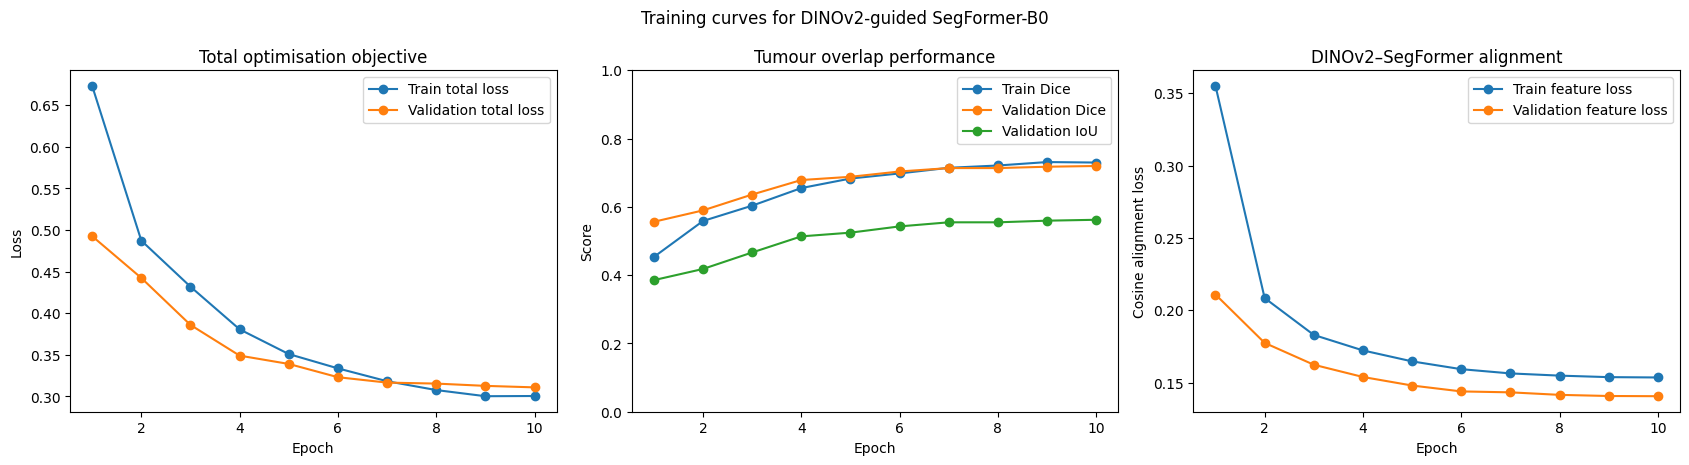

In [13]:
# =============================================================================
# Curves for supervised learning and DINOv2 feature guidance
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.7))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train total loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation total loss")
axes[0].set_title("Total optimisation objective")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_dice"], marker="o", label="Train Dice")
axes[1].plot(history_df["epoch"], history_df["val_dice"], marker="o", label="Validation Dice")
axes[1].plot(history_df["epoch"], history_df["val_iou"], marker="o", label="Validation IoU")
axes[1].set_title("Tumour overlap performance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()

if DINO_GUIDANCE_ENABLED:
    axes[2].plot(
        history_df["epoch"], history_df["train_alignment_loss"], marker="o",
        label="Train feature loss"
    )
    axes[2].plot(
        history_df["epoch"], history_df["val_alignment_loss"], marker="o",
        label="Validation feature loss"
    )
    axes[2].set_title("DINOv2–SegFormer alignment")
    axes[2].set_ylabel("Cosine alignment loss")
else:
    axes[2].plot(
        history_df["epoch"], history_df["val_pixel_accuracy"], marker="o",
        label="Validation pixel accuracy"
    )
    axes[2].set_title("DINOv2 unavailable: baseline run")
    axes[2].set_ylabel("Accuracy")
    axes[2].set_ylim(0, 1)

axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("Training curves for DINOv2-guided SegFormer-B0")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_and_alignment_curves.png", dpi=220, bbox_inches="tight")
plt.show()

## 11. Final evaluation using the best validation checkpoint

Teacher features are not required at prediction time. The best student checkpoint is therefore evaluated on the test split using only SegFormer mask predictions.

In [14]:
# =============================================================================
# Load best student model and evaluate without teacher computation
# =============================================================================
best_checkpoint = torch.load(best_checkpoint_path, map_location=device)
guided_model.student.load_state_dict(best_checkpoint["student_state_dict"])

if (
    guided_model.student_adapter is not None
    and best_checkpoint["adapter_state_dict"] is not None
):
    guided_model.student_adapter.load_state_dict(best_checkpoint["adapter_state_dict"])

guided_model.eval()

def evaluate_student_inference(model, loader):
    """
    Evaluate final segmentation behaviour without requesting DINOv2 features.
    This represents deployed SegFormer inference.
    """
    total_loss = 0.0
    total_samples = 0
    tp = fp = fn = correct = pixels = 0

    with torch.inference_mode():
        for images, masks in tqdm(loader, desc="Testing SegFormer student", leave=False):
            images = images.to(device, non_blocking=PIN_MEMORY).contiguous()
            masks = masks.to(device, non_blocking=PIN_MEMORY).contiguous()

            with amp_context():
                model_output = model(images, request_teacher_features=False)

            # Test loss reports the supervised mask objective only.
            logits = model_output["logits"].float()
            supervised_loss = (
                F.cross_entropy(logits, masks)
                + DICE_WEIGHT * foreground_dice_loss(logits, masks)
            )

            batch_tp, batch_fp, batch_fn, batch_correct, batch_pixels = accumulate_binary_counts(
                logits, masks
            )
            tp += batch_tp
            fp += batch_fp
            fn += batch_fn
            correct += batch_correct
            pixels += batch_pixels

            batch_size = images.shape[0]
            total_loss += supervised_loss.item() * batch_size
            total_samples += batch_size

    statistics = metrics_from_counts(tp, fp, fn, correct, pixels)
    statistics["supervised_loss"] = total_loss / max(total_samples, 1)
    return statistics


test_statistics = evaluate_student_inference(guided_model, test_loader)

test_report = pd.DataFrame([{
    "Selected validation epoch": best_checkpoint["epoch"],
    "DINOv2 guidance active during training": best_checkpoint["dino_guidance_enabled"],
    "Test supervised loss": test_statistics["supervised_loss"],
    "Test Dice": test_statistics["dice"],
    "Test IoU": test_statistics["iou"],
    "Test pixel accuracy": test_statistics["pixel_accuracy"],
}])

display(test_report.round(4))
test_report.to_csv(OUTPUT_DIR / "test_metrics.csv", index=False)

Testing SegFormer student:   0%|          | 0/54 [00:00<?, ?it/s]

,Selected validation epoch,DINOv2 guidance active during training,Test supervised loss,Test Dice,Test IoU,Test pixel accuracy
0,10,True,0.3031,0.7096,0.5499,0.9791


## 12. Qualitative mask interpretation

The six-panel output provides complementary evidence:

- the MRI slice and ground-truth tumour mask identify the supervised target;
- the probability map reveals confidence distribution;
- the thresholded mask and overlay display the final segmentation;
- the error map separates false-positive and false-negative pixels.

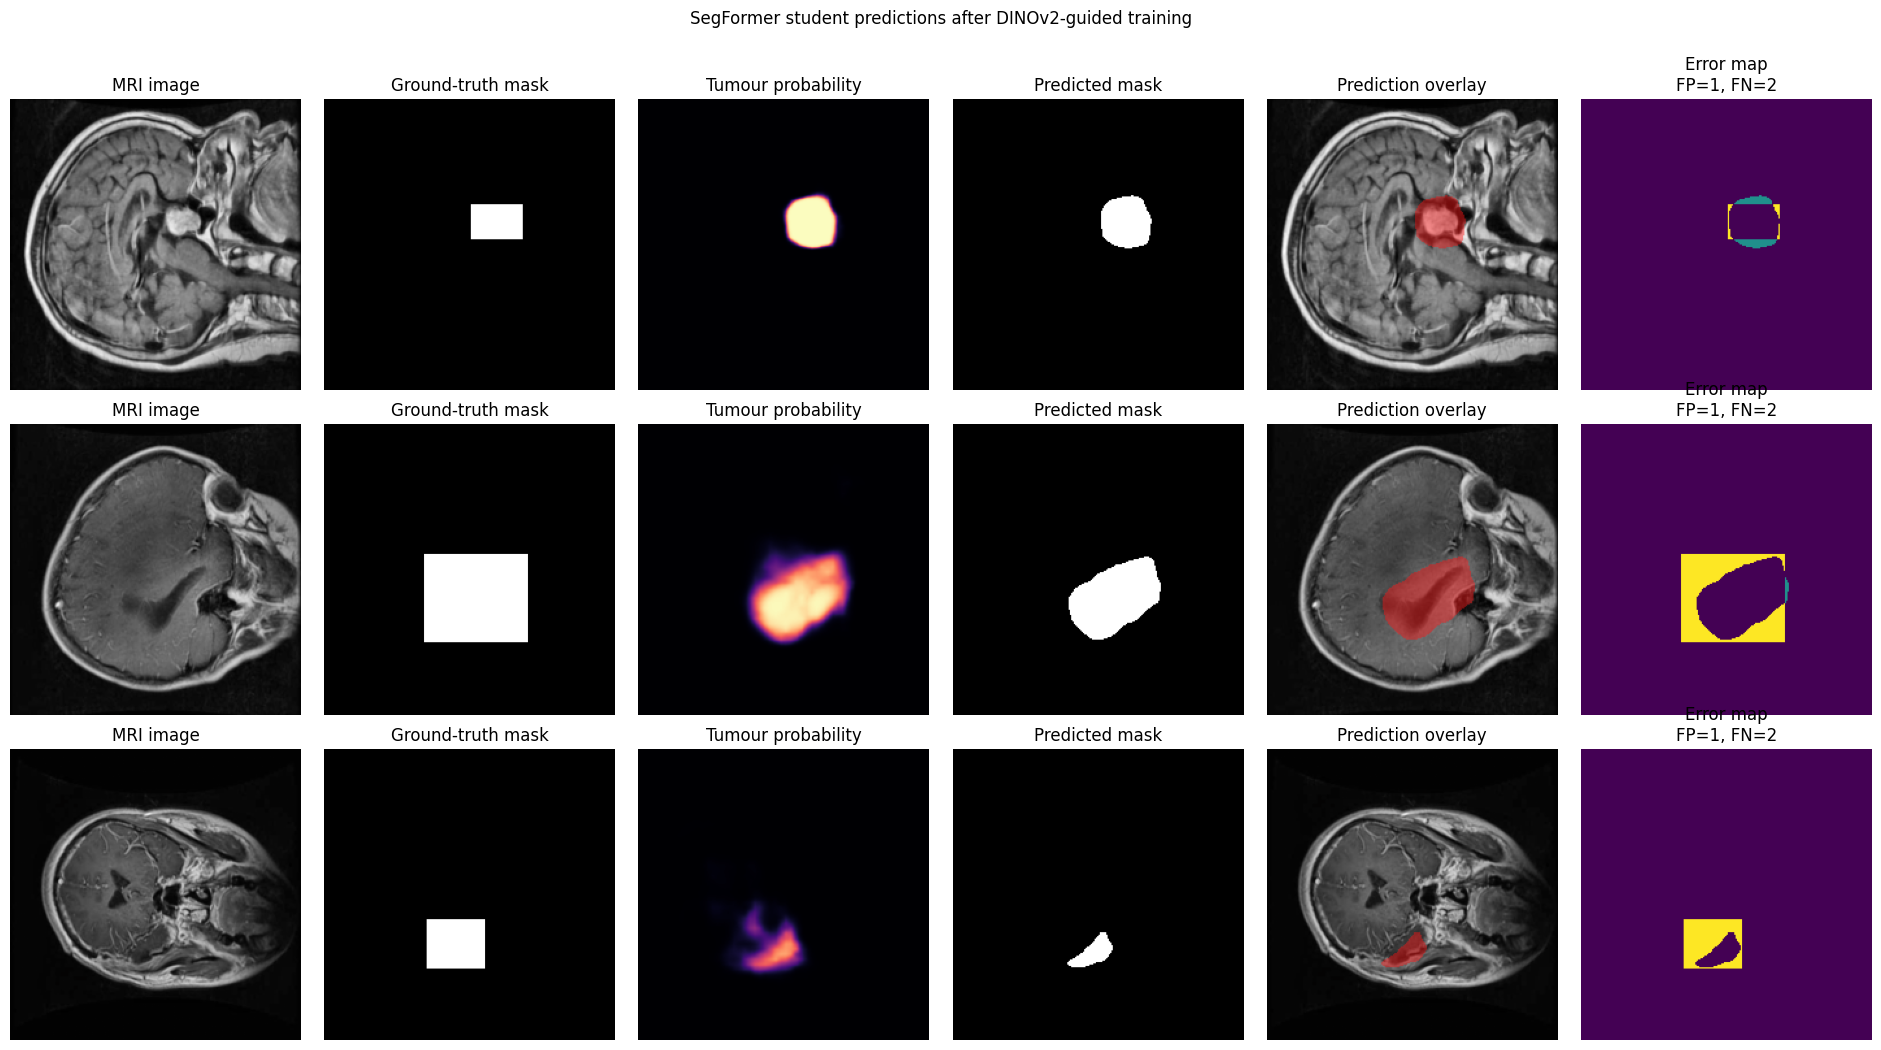

In [15]:
# =============================================================================
# Qualitative segmentation panels
# =============================================================================
DISPLAY_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
DISPLAY_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def displayable_image(image_tensor: torch.Tensor):
    """Invert input normalisation for plotting."""
    reconstructed = (image_tensor.cpu() * DISPLAY_STD + DISPLAY_MEAN).clamp(0, 1)
    return reconstructed.permute(1, 2, 0).numpy()


def visualise_test_predictions(model, dataset, fractions, number_of_examples=3):
    """Plot MRI, target, probability, binary prediction, overlay, and error map."""
    positive_indices = np.where(fractions > 0)[0]
    if len(positive_indices) == 0:
        positive_indices = np.arange(min(number_of_examples, len(dataset)))

    selected = positive_indices[
        np.linspace(0, len(positive_indices) - 1,
                    min(number_of_examples, len(positive_indices)), dtype=int)
    ]

    fig, axes = plt.subplots(len(selected), 6, figsize=(19, 3.45 * len(selected)))
    axes = np.atleast_2d(axes)

    for row, index in enumerate(selected):
        image_tensor, target_tensor = dataset[int(index)]
        input_tensor = image_tensor.unsqueeze(0).to(device).contiguous()

        with torch.inference_mode():
            with amp_context():
                output = model(input_tensor, request_teacher_features=False)
            probability = torch.softmax(output["logits"].float(), dim=1)[0, 1].cpu().numpy()

        target = target_tensor.numpy().astype(np.uint8)
        prediction = (probability >= 0.5).astype(np.uint8)
        image = displayable_image(image_tensor)

        overlay = image.copy()
        overlay[prediction == 1] = (
            0.55 * overlay[prediction == 1] + 0.45 * np.array([1.0, 0.08, 0.08])
        )

        # Error encoding: 0 = correct, 1 = false positive, 2 = false negative.
        error_map = np.zeros_like(target, dtype=np.uint8)
        error_map[(prediction == 1) & (target == 0)] = 1
        error_map[(prediction == 0) & (target == 1)] = 2

        panels = [
            (image, "MRI image", None, None),
            (target, "Ground-truth mask", "gray", 1),
            (probability, "Tumour probability", "magma", 1),
            (prediction, "Predicted mask", "gray", 1),
            (overlay, "Prediction overlay", None, None),
            (error_map, "Error map\nFP=1, FN=2", "viridis", 2),
        ]

        for column, (panel, title, colour_map, maximum) in enumerate(panels):
            axes[row, column].imshow(
                panel, cmap=colour_map,
                vmin=0 if colour_map is not None else None,
                vmax=maximum
            )
            axes[row, column].set_title(title)
            axes[row, column].axis("off")

    plt.suptitle("SegFormer student predictions after DINOv2-guided training", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "qualitative_segmentation_outputs.png", dpi=220, bbox_inches="tight")
    plt.show()


visualise_test_predictions(guided_model, test_dataset, test_fractions, number_of_examples=3)

## 13. Spatial feature-response comparison

A spatial response map is formed by averaging the absolute activation magnitude across feature channels and upsampling the result for display. It should be interpreted as a representation diagnostic, **not** as a clinically validated explanation map or as a replacement for the predicted mask.

The visual comparison includes:

- the frozen DINOv2 teacher, when pretrained weights are available;
- the initial SegFormer MiT encoder;
- the SegFormer MiT encoder after segmentation training.

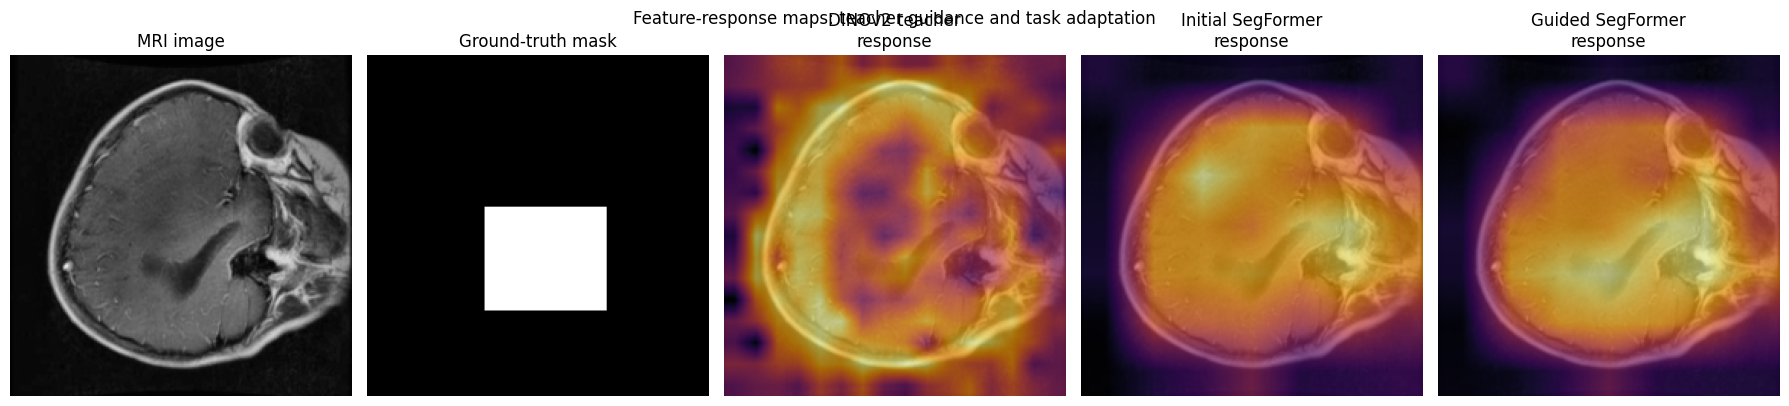

In [16]:
# =============================================================================
# Spatial representation diagnostics
# =============================================================================
def normalise_response(response_array: np.ndarray):
    """Map an activation response image to the display interval [0, 1]."""
    minimum = response_array.min()
    maximum = response_array.max()
    return (response_array - minimum) / (maximum - minimum + 1e-8)


def segformer_response_map(encoder, image_tensor):
    """Obtain the mean activation magnitude of the final MiT feature map."""
    encoder = encoder.to(device).eval()
    batch = image_tensor.unsqueeze(0).to(device).contiguous()

    with torch.inference_mode():
        output = encoder(pixel_values=batch, output_hidden_states=True, return_dict=True)
        feature_map = ensure_spatial_map(output.last_hidden_state)
        response = feature_map.abs().mean(dim=1, keepdim=True)
        response = F.interpolate(
            response, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
        )[0, 0].float().cpu().numpy()

    encoder.cpu()
    return normalise_response(response)


def dinov2_response_map(teacher, image_tensor):
    """Obtain a spatial response map from DINOv2 patch-token activations."""
    if teacher is None:
        return None

    teacher = teacher.to(device).eval()
    batch = image_tensor.unsqueeze(0).to(device).contiguous()

    with torch.inference_mode():
        output = teacher(pixel_values=batch)
        patch_tokens = output.last_hidden_state[:, 1:, :]
        side = int(math.sqrt(patch_tokens.shape[1]))
        feature_map = patch_tokens.transpose(1, 2).reshape(
            1, patch_tokens.shape[-1], side, side
        )
        response = feature_map.abs().mean(dim=1, keepdim=True)
        response = F.interpolate(
            response, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
        )[0, 0].float().cpu().numpy()

    return normalise_response(response)


positive_test_indices = np.where(test_fractions > 0)[0]
response_index = (
    int(positive_test_indices[len(positive_test_indices) // 2])
    if len(positive_test_indices) > 0 else 0
)
response_image_tensor, response_target = test_dataset[response_index]
response_image = displayable_image(response_image_tensor)

initial_student_response = segformer_response_map(initial_student_encoder, response_image_tensor)
trained_student_response = segformer_response_map(guided_model.student.segformer, response_image_tensor)
guided_model.student.segformer.to(device)

teacher_response = (
    dinov2_response_map(guided_model.teacher, response_image_tensor)
    if DINO_GUIDANCE_ENABLED else None
)

panel_items = [
    (response_image, "MRI image", None),
    (response_target.numpy(), "Ground-truth mask", "gray"),
]
if teacher_response is not None:
    panel_items.append((teacher_response, "DINOv2 teacher\nresponse", "inferno"))
panel_items.extend([
    (initial_student_response, "Initial SegFormer\nresponse", "inferno"),
    (trained_student_response, "Guided SegFormer\nresponse", "inferno"),
])

fig, axes = plt.subplots(1, len(panel_items), figsize=(3.6 * len(panel_items), 4.1))
axes = np.atleast_1d(axes)

for axis, (panel, title, colour_map) in zip(axes, panel_items):
    if title in ["MRI image"]:
        axis.imshow(panel)
    elif title == "Ground-truth mask":
        axis.imshow(panel, cmap=colour_map, vmin=0, vmax=1)
    else:
        axis.imshow(response_image)
        axis.imshow(panel, cmap=colour_map, alpha=0.65, vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")

plt.suptitle("Feature-response maps: teacher guidance and task adaptation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spatial_feature_response_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

## 14. t-SNE representation visualisation

For pedagogical analysis, an embedding is created by globally averaging the final spatial feature map. t-SNE is fitted separately for each feature source because their representations occupy different vector spaces. Accordingly, students should compare neighbourhood patterns and group mixing rather than absolute two-dimensional coordinates.

Point colours indicate annotated foreground-area groups, not tumour subtype or diagnosis.

Extracting SegFormer embeddings:   0%|          | 0/54 [00:00<?, ?it/s]

Extracting SegFormer embeddings:   0%|          | 0/54 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a77d39b6f20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a77d39b6f20>^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ 

Extracting DINOv2 embeddings:   0%|          | 0/54 [00:00<?, ?it/s]

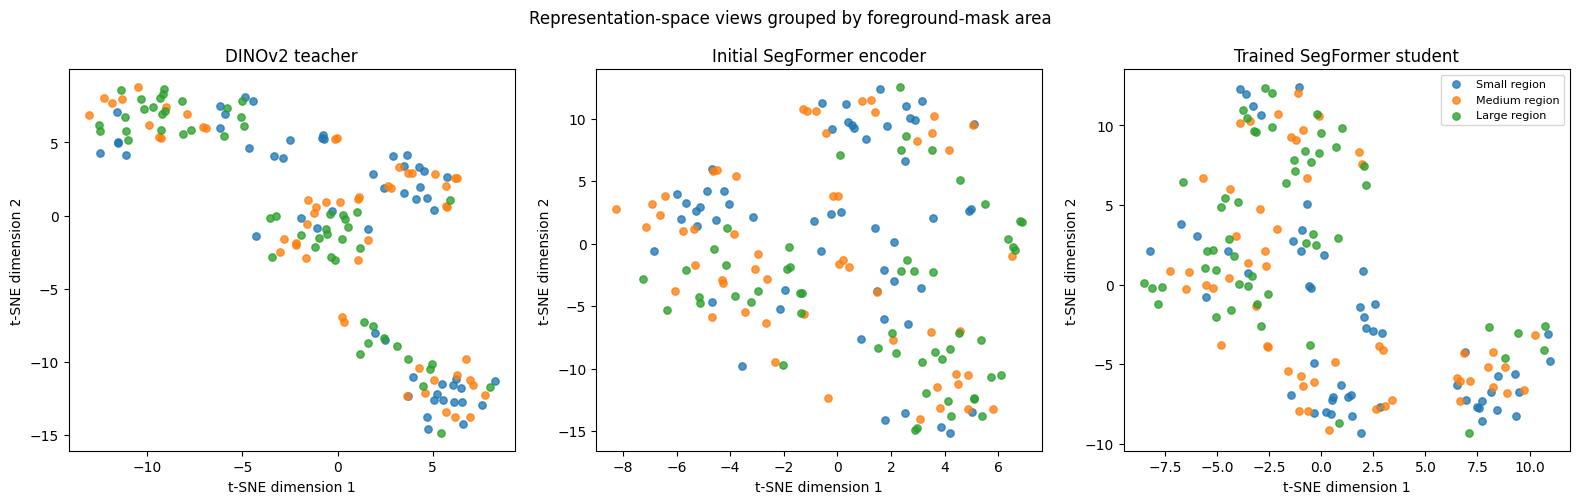

In [17]:
# =============================================================================
# Feature-space analysis with t-SNE
# =============================================================================
def assign_foreground_area_groups(fractions):
    """Categorise samples according to annotated foreground burden."""
    positive_values = fractions[fractions > 0]
    if len(positive_values) >= 3:
        first_threshold, second_threshold = np.quantile(positive_values, [0.33, 0.67])
    else:
        first_threshold, second_threshold = 0.01, 0.04

    groups = []
    for value in fractions:
        if value <= 0:
            groups.append("No foreground")
        elif value <= first_threshold:
            groups.append("Small region")
        elif value <= second_threshold:
            groups.append("Medium region")
        else:
            groups.append("Large region")
    return np.asarray(groups)


def extract_segformer_embeddings(encoder, loader, maximum_samples):
    """Create one global embedding vector per MRI image from a MiT encoder."""
    encoder = encoder.to(device).eval()
    embeddings = []
    collected = 0

    with torch.inference_mode():
        for images, _ in tqdm(loader, desc="Extracting SegFormer embeddings", leave=False):
            images = images.to(device, non_blocking=PIN_MEMORY).contiguous()
            with amp_context():
                output = encoder(pixel_values=images, return_dict=True)
            spatial_features = ensure_spatial_map(output.last_hidden_state)
            global_features = F.adaptive_avg_pool2d(spatial_features.float(), 1).flatten(1)
            embeddings.append(global_features.cpu().numpy())
            collected += images.shape[0]
            if collected >= maximum_samples:
                break

    encoder.cpu()
    return np.concatenate(embeddings, axis=0)[:maximum_samples]


def extract_dinov2_embeddings(teacher, loader, maximum_samples):
    """Create global embeddings by averaging DINOv2 patch tokens."""
    teacher = teacher.to(device).eval()
    embeddings = []
    collected = 0

    with torch.inference_mode():
        for images, _ in tqdm(loader, desc="Extracting DINOv2 embeddings", leave=False):
            images = images.to(device, non_blocking=PIN_MEMORY).contiguous()
            with amp_context():
                output = teacher(pixel_values=images)
            patch_embedding = output.last_hidden_state[:, 1:, :].float().mean(dim=1)
            embeddings.append(patch_embedding.cpu().numpy())
            collected += images.shape[0]
            if collected >= maximum_samples:
                break

    return np.concatenate(embeddings, axis=0)[:maximum_samples]


tsne_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
number_of_tsne_samples = min(160, len(test_dataset))
tsne_groups = assign_foreground_area_groups(test_fractions[:number_of_tsne_samples])

if number_of_tsne_samples >= 8:
    initial_embeddings = extract_segformer_embeddings(
        initial_student_encoder, tsne_loader, number_of_tsne_samples
    )
    trained_embeddings = extract_segformer_embeddings(
        guided_model.student.segformer, tsne_loader, number_of_tsne_samples
    )
    guided_model.student.segformer.to(device)

    embedding_sets = [
        ("Initial SegFormer encoder", initial_embeddings),
        ("Trained SegFormer student", trained_embeddings),
    ]

    if DINO_GUIDANCE_ENABLED:
        teacher_embeddings = extract_dinov2_embeddings(
            guided_model.teacher, tsne_loader, number_of_tsne_samples
        )
        embedding_sets.insert(0, ("DINOv2 teacher", teacher_embeddings))

    perplexity = min(30, max(5, (number_of_tsne_samples - 1) // 3))
    projected_sets = []
    for title, embeddings in embedding_sets:
        projection = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=SEED
        ).fit_transform(embeddings)
        projected_sets.append((title, projection))

    categories = ["No foreground", "Small region", "Medium region", "Large region"]
    fig, axes = plt.subplots(
        1, len(projected_sets),
        figsize=(5.3 * len(projected_sets), 5.1)
    )
    axes = np.atleast_1d(axes)

    for axis, (title, projection) in zip(axes, projected_sets):
        for category in categories:
            selected = tsne_groups == category
            if selected.any():
                axis.scatter(
                    projection[selected, 0],
                    projection[selected, 1],
                    s=28,
                    alpha=0.78,
                    label=category
                )
        axis.set_title(title)
        axis.set_xlabel("t-SNE dimension 1")
        axis.set_ylabel("t-SNE dimension 2")

    axes[-1].legend(loc="best", fontsize=8)
    plt.suptitle("Representation-space views grouped by foreground-mask area")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "tsne_representation_comparison.png", dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("The test split contains too few samples for a meaningful t-SNE plot.")

## 15. Interpretation guide and saved outputs

### Points for classroom discussion

1. **Mask conversion:** the foreground overlay confirms whether COCO polygons have been correctly merged into one binary target.
2. **Architectural compatibility:** DINOv2 and MiT-B0 cannot be joined by copying encoder weights; their interaction is realised through a representation-alignment objective.
3. **Teacher guidance:** a decreasing alignment loss suggests that the trained SegFormer feature map becomes closer to the frozen DINOv2 teacher representation. This trend should be considered alongside segmentation Dice and IoU rather than in isolation.
4. **Prediction evidence:** a probability map exposes uncertain pixels that are hidden by the thresholded mask; an error map distinguishes over-segmentation from missed tumour pixels.
5. **Representation analysis:** feature-response and t-SNE figures are descriptive tools for understanding network behaviour. They do not establish medical reliability.

### Output files

The executed notebook saves the following under `/kaggle/working/dinov2_guided_segformer_brain_tumour/`:

- `dataset_foreground_summary.csv`;
- `training_history.csv`;
- `test_metrics.csv`;
- `checkpoints/best_dinov2_guided_segformer_b0.pt`;
- workflow, annotation, training, prediction, response-map, and t-SNE figures under `figures/`.

### Closing summary

This notebook uses DINOv2 as a frozen self-supervised teacher and SegFormer-B0 as a dense prediction student. The formulation preserves the architecture of SegFormer, prevents invalid cross-architecture weight transfer, and gives students a concrete example of representation-guided semantic segmentation.

In [18]:
# =============================================================================
# Record all generated experiment artefacts for retrieval from Kaggle output.
# =============================================================================
generated_files = sorted(
    str(path.relative_to(OUTPUT_DIR))
    for path in OUTPUT_DIR.rglob("*")
    if path.is_file()
)

print("Generated output files:")
for generated_file in generated_files:
    print(f" - {generated_file}")

run_description = {
    "course": "CSE 438: Digital Image Processing",
    "instructor": "Dr Md Rifat Ahmmad Rashid",
    "architecture": "DINOv2 frozen teacher with SegFormer-B0 student",
    "teacher_guidance_enabled": bool(DINO_GUIDANCE_ENABLED),
    "dino_status": DINO_STATUS,
    "segformer_status": SEGFORMER_STATUS,
}
with open(OUTPUT_DIR / "run_description.json", "w", encoding="utf-8") as file:
    json.dump(run_description, file, indent=2)

print("Run-description record saved.")

Generated output files:
 - checkpoints/best_dinov2_guided_segformer_b0.pt
 - dataset_foreground_summary.csv
 - figures/annotation_overlay_examples.png
 - figures/dinov2_segformer_feature_guidance_workflow.png
 - figures/foreground_area_distribution.png
 - figures/qualitative_segmentation_outputs.png
 - figures/spatial_feature_response_comparison.png
 - figures/training_and_alignment_curves.png
 - figures/tsne_representation_comparison.png
 - test_metrics.csv
 - training_history.csv
Run-description record saved.
